In [1]:
### import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
data = pd.read_csv("Temps.csv")
data.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


> Şuan elimizdeki veri seti farklı ülkelerdeki ve farklı şehirlerdeki tarihlere göre ortalama sıcaklıklarını gösteriyor.

**VARİABLES**
* **date** : tarih 
* **AverageTemperature** : Ortalama Sıcaklık
* **AverageTemperatureUncertainty** : Ortalama Sıcaklık Belirsizliği
* **City** : Şehir
* **Country** : Ülke 
* **Latitude** : Enlem
* **Longtitude** : Boylam

In [8]:
data.dtypes

dt                                object
AverageTemperature               float64
AverageTemperatureUncertainty    float64
City                              object
Country                           object
Latitude                          object
Longitude                         object
dtype: object

In [15]:
data = pd.read_csv("Temps.csv",parse_dates = ["dt"])
data.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [24]:
data.columns

Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City',
       'Country', 'Latitude', 'Longitude'],
      dtype='object')

In [9]:
data.dtypes

dt                               datetime64[ns]
AverageTemperature                      float64
AverageTemperatureUncertainty           float64
City                                     object
Country                                  object
Latitude                                 object
Longitude                                object
dtype: object

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8599212 entries, 0 to 8599211
Data columns (total 7 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   dt                             datetime64[ns]
 1   AverageTemperature             float64       
 2   AverageTemperatureUncertainty  float64       
 3   City                           object        
 4   Country                        object        
 5   Latitude                       object        
 6   Longitude                      object        
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 459.2+ MB


In [25]:
# boyut bilgisi
data.shape

(8599212, 7)

In [7]:
data.describe()

,AverageTemperature,AverageTemperatureUncertainty
count,8.235082e+06,8.235082e+06
mean,1.672743e+01,1.028575e+00
std,1.035344e+01,1.129733e+00
min,-4.270400e+01,3.400000e-02
25%,1.029900e+01,3.370000e-01
50%,1.883100e+01,5.910000e-01
75%,2.521000e+01,1.349000e+00
max,3.965100e+01,1.539600e+01


In [ ]:
data.isnull()    # isnull yerine isna metodunu da kullanabiliriz.

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,False,False,False,False,False,False,False
1,False,True,True,False,False,False,False
2,False,True,True,False,False,False,False
3,False,True,True,False,False,False,False
4,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...
8599207,False,False,False,False,False,False,False
8599208,False,False,False,False,False,False,False
8599209,False,False,False,False,False,False,False
8599210,False,False,False,False,False,False,False


In [23]:
# hangi sütunda kaç eksik değer var
data.isnull().sum()

dt                                    0
AverageTemperature               364130
AverageTemperatureUncertainty    364130
City                                  0
Country                               0
Latitude                              0
Longitude                             0
dtype: int64

In [11]:
# sütunlardaki toplam eksik değer
data.isnull().sum().sum()

728260

In [21]:
# sütunlardaki eksik değerlerin ortalama yüzdelikleri
(data.isna().sum() / data.index.size) * 100

dt                               0.000000
AverageTemperature               4.234458
AverageTemperatureUncertainty    4.234458
City                             0.000000
Country                          0.000000
Latitude                         0.000000
Longitude                        0.000000
dtype: float64

In [26]:
# eksik verileri kalıcı olarak silme
data.dropna(inplace=True)

print(data.isnull().sum())
data

dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
City                             0
Country                          0
Latitude                         0
Longitude                        0
dtype: int64


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
5,1744-04-01,5.788,3.624,Århus,Denmark,57.05N,10.33E
6,1744-05-01,10.644,1.283,Århus,Denmark,57.05N,10.33E
7,1744-06-01,14.051,1.347,Århus,Denmark,57.05N,10.33E
8,1744-07-01,16.082,1.396,Århus,Denmark,57.05N,10.33E
...,...,...,...,...,...,...,...
8599206,2013-04-01,7.710,0.182,Zwolle,Netherlands,52.24N,5.26E
8599207,2013-05-01,11.464,0.236,Zwolle,Netherlands,52.24N,5.26E
8599208,2013-06-01,15.043,0.261,Zwolle,Netherlands,52.24N,5.26E
8599209,2013-07-01,18.775,0.193,Zwolle,Netherlands,52.24N,5.26E


In [40]:
data["Country"].value_counts().head(66)  # burada ülkelerin frekanslarının büyükten küçüğe doğru sıralaması var
                                         
# aşağıdaki metod ile buradaki metodun amacı sınıfların frekanslarını bulmak ve birbirinden farkı olmaması.
# afghanistanın frekansı 16754

India            960548
China            819132
United States    661524
Brazil           451645
Russia           448663
                  ...  
Nepal             17309
Sudan             17160
Afghanistan       16754
Ghana             15939
Finland           15830
Name: Country, Length: 66, dtype: int64

In [41]:
data.groupby("Country").size()   # burada groupby dan dolayı A dan Z ye grup sıralaması var.

Country
Afghanistan    16754
Albania         9498
Algeria        15640
Angola         10372
Argentina      61968
               ...  
Venezuela      83378
Vietnam        62221
Yemen           3314
Zambia         13686
Zimbabwe       12220
Length: 159, dtype: int64

In [45]:
# kaç farklı ülke vardır 
data.Country.value_counts().count()

159

In [103]:
# türkiye veya brazilya olan verileri getir
data[(data["Country"]=="Turkey") & (data["AverageTemperature"]>30)].iloc[:100]

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
76635,2010-08-01,30.345,0.545,Adana,Turkey,36.17N,35.80E
329271,2010-08-01,30.345,0.545,Antakya,Turkey,36.17N,35.80E
747584,1812-07-01,30.523,1.445,Batman,Turkey,37.78N,40.68E
747585,1812-08-01,30.983,2.287,Batman,Turkey,37.78N,40.68E
747764,1827-07-01,30.637,1.628,Batman,Turkey,37.78N,40.68E
...,...,...,...,...,...,...,...
4563075,1860-07-01,30.254,1.085,Malatya,Turkey,37.78N,38.64E
4563076,1860-08-01,30.034,1.076,Malatya,Turkey,37.78N,38.64E
4563184,1869-08-01,30.564,1.048,Malatya,Turkey,37.78N,38.64E
4563303,1879-07-01,30.197,1.398,Malatya,Turkey,37.78N,38.64E


In [123]:
# Türkiye,Rusya ve Brezilya ülkelerindeki ortalama sıcaklığı 25 den büyük verileri alın.

data[(data["Country"].isin(["Turkey","Russia","Brazil"])) & (data["AverageTemperature"]>25)].iloc[2000:8000]

# isin metoduyla bir değişkendeki birçok sınıfı topluca alabiliyoruz.

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
158744,1880-08-01,25.875,0.677,Alanya,Turkey,36.17N,31.82E
158756,1881-08-01,26.745,1.184,Alanya,Turkey,36.17N,31.82E
158767,1882-07-01,25.077,1.232,Alanya,Turkey,36.17N,31.82E
158768,1882-08-01,25.277,0.646,Alanya,Turkey,36.17N,31.82E
158779,1883-07-01,25.317,1.103,Alanya,Turkey,36.17N,31.82E
...,...,...,...,...,...,...,...
374984,1923-07-01,25.407,0.580,Araguaína,Brazil,7.23S,47.84W
374985,1923-08-01,27.138,0.558,Araguaína,Brazil,7.23S,47.84W
374986,1923-09-01,27.265,0.928,Araguaína,Brazil,7.23S,47.84W
374987,1923-10-01,26.461,0.526,Araguaína,Brazil,7.23S,47.84W


In [23]:
data[data["Country"].isin(["Turkey","China","Yemen","Argentina"])].groupby("Country")[["AverageTemperature","AverageTemperatureUncertainty"]].aggregate([np.mean,np.std,"max","min"])

AverageTemperature                             \
                        mean        std     max     min   
Country                                                   
Argentina          16.999216   5.866689  29.509  -1.460   
China              12.542541  11.783872  31.799 -34.940   
Turkey             12.951888   8.095932  32.885 -15.353   
Yemen              25.768408   2.604266  31.085  19.926   

          AverageTemperatureUncertainty                          
                                   mean       std    max    min  
Country                                                          
Argentina                      0.728985  0.568722  6.388  0.054  
China                          0.866806  0.704876  9.595  0.049  
Turkey                         1.275864  1.152891  9.237  0.056  
Yemen                          0.958633  0.507199  4.064  0.220

In [52]:
# en yüksek ortalama sıcaklık hangi ülke ve şehire aittir ? hangi yılda olmuştur.

data[data["AverageTemperature"] == data["AverageTemperature"].max()][["Country","City","AverageTemperature","dt"]]

,Country,City,AverageTemperature,dt
8148236,Algeria,Warqla,39.651,1761-07-01


In [76]:
# farklı ülke sınıflarındaki tüm zamanların ortalama sıcaklıkların bulunuz. ve büyükten küçüğe sıralayınız.

data.groupby("Country")[["AverageTemperature"]].mean().sort_values("AverageTemperature",ascending=False)

,AverageTemperature
Country,
Djibouti,29.152790
Niger,28.145552
Sudan,28.072831
Burkina Faso,27.815295
Mali,27.590491
...,...
Finland,3.711645
Norway,3.612553
Russia,3.347268


In [69]:
# veride yer alan farklı ülke sınıflarındaki tüm zamanların ortalama sıcaklıklarını bulup , dünya genelinde tüm zamanların ortalama sıcaklığını bulunuz.

(data.groupby("Country")[["AverageTemperature"]].mean().sum()) / (data.Country.value_counts().count())

AverageTemperature    18.450474
dtype: float64

In [129]:
# türkiye ülkesindeki şehirlerin en eski tarihten(1743) günümüze kadar hangi tarihlerde hangi şehrin ortalama sıcaklığı ne kadar gösteriniz.

data[data["Country"]=="Turkey"][["AverageTemperature","City","dt"]].sort_values(["dt","AverageTemperature"])

,AverageTemperature,City,dt
2159852,6.176,Edirne,1743-11-01
8582196,6.841,Zonguldak,1743-11-01
1223843,7.277,Bursa,1743-11-01
3184140,7.277,Inegol,1743-11-01
3536924,7.277,Kütahya,1743-11-01
...,...,...,...
749997,29.915,Batman,2013-08-01
8064196,29.915,Viransehir,2013-08-01
4564912,29.940,Malatya,2013-08-01
7053056,29.940,Siverek,2013-08-01


In [138]:
# Türkiyede 1743 yılında şehirlerdeki ortalama sıcaklıklar
veri_1 = data[(data["Country"]=="Turkey") & (data["dt"]=="1743-11-01")]
veri_1

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
3239,1743-11-01,10.013,2.291,Çorlu,Turkey,40.99N,27.69E
1223843,1743-11-01,7.277,2.308,Bursa,Turkey,39.38N,29.13E
2159852,1743-11-01,6.176,2.264,Edirne,Turkey,42.59N,26.18E
2254647,1743-11-01,10.013,2.291,Esenyurt,Turkey,40.99N,27.69E
2523278,1743-11-01,10.365,2.325,Gebze,Turkey,40.99N,29.82E
3184140,1743-11-01,7.277,2.308,Inegol,Turkey,39.38N,29.13E
3256834,1743-11-01,10.365,2.325,Istanbul,Turkey,40.99N,29.82E
3306430,1743-11-01,10.365,2.325,Izmit,Turkey,40.99N,29.82E
3536924,1743-11-01,7.277,2.308,Kütahya,Turkey,39.38N,29.13E
4611138,1743-11-01,11.478,2.247,Manisa,Turkey,39.38N,27.05E


In [139]:
# Türkiyede 2013 yılındaki şehirlerdeki ortalama sıcaklıklar
veri_2 = data[(data["Country"]=="Turkey") & (data["dt"]=="2013-08-01")]
veri_2

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
6476,2013-08-01,25.246,0.375,Çorlu,Turkey,40.99N,27.69E
9605,2013-08-01,21.452,0.344,Çorum,Turkey,40.99N,34.08E
76671,2013-08-01,27.986,0.485,Adana,Turkey,36.17N,35.80E
92982,2013-08-01,23.173,0.368,Afyonkarahisar,Turkey,39.38N,31.21E
143110,2013-08-01,22.621,0.406,Aksaray,Turkey,37.78N,34.58E
160340,2013-08-01,27.254,0.537,Alanya,Turkey,36.17N,31.82E
314955,2013-08-01,22.625,0.371,Ankara,Turkey,39.38N,33.29E
329307,2013-08-01,27.986,0.485,Antakya,Turkey,36.17N,35.80E
332184,2013-08-01,24.021,0.287,Antalya,Turkey,37.78N,30.51E
749997,2013-08-01,29.915,0.292,Batman,Turkey,37.78N,40.68E


In [142]:
# Türkiyede 1743-11-01 tarihinden bu yana türkiye ortalama sıcaklığı kaç derece artmıştır ? (2013 yılındaki max ort. sıcaklık değeri, 1743 yılındaki min ort. sıcaklık değeri baz alınmıştır.)
(veri_2["AverageTemperature"].max())-(veri_1["AverageTemperature"].min())

23.764000000000003

In [219]:
new_data_1 = data[data["Country"]=="Turkey"]
new_data_1

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
3239,1743-11-01,10.013,2.291,Çorlu,Turkey,40.99N,27.69E
3244,1744-04-01,13.685,2.162,Çorlu,Turkey,40.99N,27.69E
3245,1744-05-01,15.021,1.824,Çorlu,Turkey,40.99N,27.69E
3246,1744-06-01,19.663,1.701,Çorlu,Turkey,40.99N,27.69E
3247,1744-07-01,22.314,1.648,Çorlu,Turkey,40.99N,27.69E
...,...,...,...,...,...,...,...
8585429,2013-04-01,11.876,0.293,Zonguldak,Turkey,40.99N,31.95E
8585430,2013-05-01,17.662,0.196,Zonguldak,Turkey,40.99N,31.95E
8585431,2013-06-01,19.818,0.344,Zonguldak,Turkey,40.99N,31.95E
8585432,2013-07-01,21.343,0.288,Zonguldak,Turkey,40.99N,31.95E


In [220]:
new_data_2 = data[data["Country"]=="Brazil"]
new_data_2

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
152741,1832-01-01,25.953,1.570,Alagoinhas,Brazil,12.05S,37.81W
152742,1832-02-01,25.933,2.372,Alagoinhas,Brazil,12.05S,37.81W
152743,1832-03-01,25.968,1.585,Alagoinhas,Brazil,12.05S,37.81W
152744,1832-04-01,25.100,2.175,Alagoinhas,Brazil,12.05S,37.81W
152745,1832-05-01,24.213,1.809,Alagoinhas,Brazil,12.05S,37.81W
...,...,...,...,...,...,...,...
8109067,2013-04-01,20.240,0.483,Volta Redonda,Brazil,21.70S,44.13W
8109068,2013-05-01,18.377,0.527,Volta Redonda,Brazil,21.70S,44.13W
8109069,2013-06-01,18.072,0.398,Volta Redonda,Brazil,21.70S,44.13W
8109070,2013-07-01,17.539,0.646,Volta Redonda,Brazil,21.70S,44.13W


In [236]:
new_data_3 = data[data["Country"]=="Denmark"]
new_data_3

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
5,1744-04-01,5.788,3.624,Århus,Denmark,57.05N,10.33E
6,1744-05-01,10.644,1.283,Århus,Denmark,57.05N,10.33E
7,1744-06-01,14.051,1.347,Århus,Denmark,57.05N,10.33E
8,1744-07-01,16.082,1.396,Århus,Denmark,57.05N,10.33E
...,...,...,...,...,...,...,...
5412618,2013-04-01,6.026,0.333,Odense,Denmark,55.45N,11.34E
5412619,2013-05-01,12.774,0.426,Odense,Denmark,55.45N,11.34E
5412620,2013-06-01,15.685,0.370,Odense,Denmark,55.45N,11.34E
5412621,2013-07-01,18.735,0.441,Odense,Denmark,55.45N,11.34E


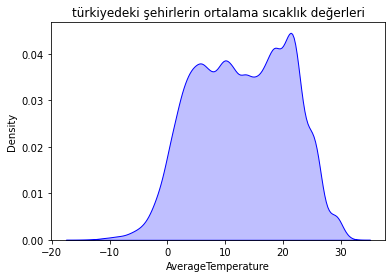

In [249]:
# türkiyedeki şehirlerin ortalama sıcaklık değerlerinin yoğunluk grafiğiyle dağılımı
(sns.kdeplot(new_data_1.AverageTemperature,shade=True,color="blue")
.set_title("türkiyedeki şehirlerin ortalama sıcaklık değerleri"));

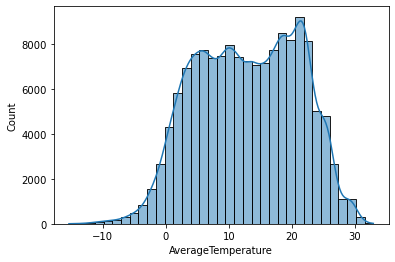

In [222]:
# türkiyedeki şehirlerin ortalama sıcaklık değerlerinin histogram grafiğiyle gösterimi
sns.histplot(new_data_1.AverageTemperature,bins=35,kde=True);

> **Histogram ve yoğunluk grafiklerine baktığımızda ortalama sıcaklık değeri 22 civarında olan şehirler daha fazla yoğunlukta, en az yoğunlukta olan şehirlerin ortalama sıcaklıkları ise -15.35<A.T<0 ve  28<A.T<32.885**

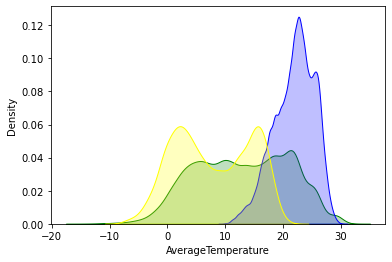

In [262]:
# Türkiye,Brezilya ve Danimarka ülkelerindeki ortalama sıcaklıklarının ülkeler bazında dağılımı

sns.kdeplot(new_data.AverageTemperature,shade=True,color="green");
sns.kdeplot(new_data_2.AverageTemperature,shade=True,color="blue");
sns.kdeplot(new_data_3.AverageTemperature,shade=True,color="yellow");

['New Zealand', 'Burkina Faso', 'Lebanon', 'United Arab Emirates'] 



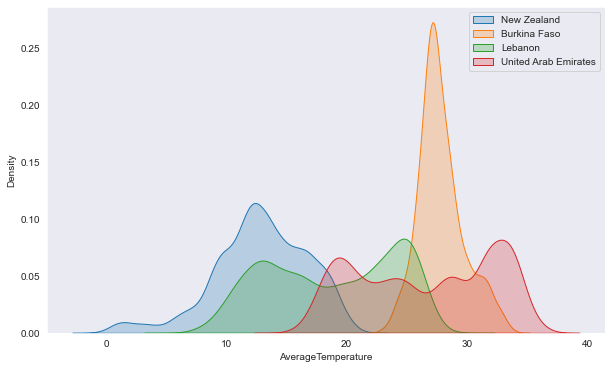

In [416]:
# Pratik yol
import random

sns.set_style("dark")  #makyaj yapma : yani grafiğin arka planını değiştirerek grafiği belirgin hale getiriyoruz.

plt.figure(figsize=(10,6))  #boyut ayarlama

country = data["Country"].unique()
liste = list(country)
sonuc = random.sample(liste,4)

grafiteki_ülkeler = []

for i in sonuc:
    grafiteki_ülkeler.append(i)
    veri = data[data["Country"]==i]
    sns.kdeplot(veri.AverageTemperature,shade=True);
    
plt.legend(sonuc)                                      # hangi renk hangi ülkeyi gösteriyor onu görmek için kullanıyoruz.
    
print(grafiteki_ülkeler,"\n")

In [417]:
# yukarıdaki her bir ülkenin ortalama sıcaklıkları dağılımının mean bilgisini bulunuz.
for a in sonuc:
    veri = data[data["Country"]==a]
    print(a,":",veri["AverageTemperature"].mean())

New Zealand : 12.84185658759645
Burkina Faso : 27.815294546436224
Lebanon : 18.759460757156088
United Arab Emirates : 26.57268054823411
